# 🛰️ Geospatial Object Detection — Improved 3-Image Pipeline (v2)

**4 Key Improvements over v1:**

| # | Problem in v1 | Fix in v2 |
|---|--------------|-----------|
| 1 | BBox drawn on synthetic dark canvas | **Real DIOR images** loaded from HuggingFace → BBoxes drawn on actual satellite imagery |
| 2 | Geo viz alone, no image beside it | **Side-by-side**: real image + geo-coord map with annotated lat/lon coordinates per object |
| 3 | All 3 images × 4 graphs crammed into one grid — unreadable | **Per-image, per-graph-type** — each image gets its own 4-panel figure (1 figure per image) |
| 4 | LLM summary shown as raw text | **Real image shown FIRST**, then LLM summary displayed richly below it |

**Selected Images (in all 3 result files, diverse non-overlapping classes):**

| Image ID | Scene | Classes | # Detections |
|----------|-------|---------|-------------|
| `001471` | Maritime Harbor | harbor, ship, vehicle | 227 |
| `000268` | Industrial Port | harbor, ship, storage_tank, vehicle | 23 |
| `000215` | Sports Complex | basketball_court, ground_track_field, stadium, vehicle | 11 |


## 📦 CELL 1: Install Dependencies

In [ ]:
!pip install ultralytics geopandas shapely matplotlib seaborn folium -q
!pip install networkx pillow requests tqdm datasets -q
!pip install google-generativeai -q

print("✅ All dependencies installed!")


## 📚 CELL 2: Imports & Global Configuration

In [ ]:
import os, json, re, warnings, time, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import geopandas as gpd
import networkx as nx
import requests
from pathlib import Path
from tqdm import tqdm
from shapely.geometry import box as shapely_box, Point
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, HTML, Markdown
from datasets import load_dataset

warnings.filterwarnings('ignore')

# ─── Selected images ────────────────────────────────────────────
SELECTED_IMAGES = ['001471', '000268', '000215']

IMAGE_META = {
    '001471': {'scene': 'Maritime Harbor',  'classes': ['harbor','ship','vehicle'],                            'n_det': 227, 'val_idx': 1471},
    '000268': {'scene': 'Industrial Port',  'classes': ['harbor','ship','storage_tank','vehicle'],             'n_det': 23,  'val_idx': 268},
    '000215': {'scene': 'Sports Complex',   'classes': ['basketball_court','ground_track_field','stadium','vehicle'], 'n_det': 11,  'val_idx': 215},
}

CLASS_NAMES = [
    'airplane','airport','baseball_field','basketball_court','bridge',
    'chimney','dam','expressway_service_area','expressway_toll_station',
    'golf_course','ground_track_field','harbor','overpass','ship',
    'stadium','storage_tank','tennis_court','train_station','vehicle','wind_mill'
]

PALETTE = {
    'harbor':'#2196F3','ship':'#F44336','vehicle':'#FF9800',
    'storage_tank':'#9C27B0','basketball_court':'#4CAF50',
    'ground_track_field':'#009688','stadium':'#E91E63',
    'tennis_court':'#00BCD4','airplane':'#607D8B','bridge':'#795548',
    'wind_mill':'#8BC34A','expressway_toll_station':'#FF5722',
    'train_station':'#3F51B5','baseball_field':'#CDDC39',
    'golf_course':'#FF6F00','default':'#9E9E9E',
}

def class_color(cls):
    return PALETTE.get(cls, PALETTE['default'])

def hex_to_rgb(h):
    return (int(h[1:3],16), int(h[3:5],16), int(h[5:7],16))

def hex_to_rgba_f(h, a=1.0):
    r,g,b = hex_to_rgb(h)
    return (r/255, g/255, b/255, a)

OUTPUT_DIR = Path('pipeline_outputs_v2')
for sub in ['bbox','geo','scene_graph','llm','reports']:
    (OUTPUT_DIR / sub).mkdir(parents=True, exist_ok=True)

print("✅ Configuration loaded!")
print(f"📁 Output directory: {OUTPUT_DIR.resolve()}")
print(f"🖼️  Processing images: {SELECTED_IMAGES}")


## 📂 CELL 3: Load Detection Result Files

In [ ]:
df_all_det = pd.read_csv('/content/detections_yolo11.csv')
df_all_det['image_str'] = df_all_det['image'].apply(lambda x: f'{int(x):06d}')

df_all_geo = pd.read_csv('/content/geo_detections (2).csv')
df_all_geo['image_str'] = df_all_geo['image'].apply(lambda x: f'{int(x):06d}')

with open('/content/dsrg_summary.json') as f:
    dsrg_summary = json.load(f)

with open('/content/detection_metrics_yolo11.json') as f:
    det_metrics = json.load(f)

df_det = df_all_det[df_all_det['image_str'].isin(SELECTED_IMAGES)].copy().reset_index(drop=True)
df_geo = df_all_geo[df_all_geo['image_str'].isin(SELECTED_IMAGES)].copy().reset_index(drop=True)

print("=" * 60)
print("📊 DATA LOADED")
print("=" * 60)
for img in SELECTED_IMAGES:
    n = len(df_det[df_det['image_str'] == img])
    cls = sorted(df_det[df_det['image_str'] == img]['class_id'].unique())
    print(f"  Image {img} ({IMAGE_META[img]['scene']}): {n} dets | classes={cls}")


## 🖼️ CELL 4: Load Real DIOR Images from HuggingFace

Loads the actual satellite imagery from the `HichTala/dior` dataset.
Image IDs 001471, 000268, 000215 correspond to **validation split indices** 1471, 268, 215.


In [ ]:
print("⏳ Loading DIOR dataset from HuggingFace (validation split only)...")
print("   This downloads ~1-2 GB on first run — subsequent runs use cache.")

# Load only the validation split to save time & memory
ds_val = load_dataset("HichTala/dior", split="validation")

print(f"✅ Loaded validation split: {len(ds_val)} images")
print(f"   Fields: {list(ds_val[0].keys())}")

# ── Extract the 3 real images ────────────────────────────────────
real_images = {}
for img_str in SELECTED_IMAGES:
    idx = IMAGE_META[img_str]['val_idx']
    sample = ds_val[idx]

    # The 'image' field is a PIL Image object in HuggingFace datasets
    pil_img = sample['image']
    if not isinstance(pil_img, Image.Image):
        pil_img = Image.fromarray(pil_img)
    pil_img = pil_img.convert('RGB')

    real_images[img_str] = pil_img
    w, h = pil_img.size
    print(f"  Image {img_str} ({IMAGE_META[img_str]['scene']}): {w}×{h} px")

print("\n✅ Real DIOR images loaded successfully!")

# ── Quick preview of all 3 real images ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Real DIOR Satellite Images (Validation Split)', fontsize=14, fontweight='bold')
fig.patch.set_facecolor('#1a1a2e')

for ax, img_str in zip(axes, SELECTED_IMAGES):
    pil_img = real_images[img_str]
    ax.imshow(pil_img)
    ax.set_title(f"Image {img_str}\n{IMAGE_META[img_str]['scene']}\n"
                 f"Index {IMAGE_META[img_str]['val_idx']} | {pil_img.size[0]}×{pil_img.size[1]} px",
                 color='white', fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bbox' / 'real_images_preview.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()
print("✅ Real image preview saved!")


## 🔍 CELL 5: YOLOv11 Bounding Boxes on Real Satellite Images [FIX #1]

**Problem Fixed:** Previous version drew bounding boxes on a synthetic dark canvas.
Now boxes are drawn directly on the **actual DIOR satellite imagery**.


In [ ]:
def draw_bbox_on_real_image(img_str, df_det_img, img_size=800):
    """Draw YOLO detection bounding boxes on the real DIOR satellite image."""
    # Get real image and resize
    pil_img = real_images[img_str].copy().resize((img_size, img_size))
    draw    = ImageDraw.Draw(pil_img)

    # Try to load a font
    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 13)
        font_sm = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 11)
    except:
        font = ImageFont.load_default()
        font_sm = font

    drawn_classes = set()
    for _, row in df_det_img.iterrows():
        cls  = row['class_id']
        conf = row['confidence']
        xc, yc, w, h = row['x_center'], row['y_center'], row['width'], row['height']

        # Normalized → pixel
        x1 = int((xc - w/2) * img_size)
        y1 = int((yc - h/2) * img_size)
        x2 = int((xc + w/2) * img_size)
        y2 = int((yc + h/2) * img_size)
        x1, y1 = max(0,x1), max(0,y1)
        x2, y2 = min(img_size,x2), min(img_size,y2)

        color_hex = class_color(cls)
        color_rgb = hex_to_rgb(color_hex)

        # Thick colored border (3px)
        draw.rectangle([x1, y1, x2, y2], outline=color_rgb, width=3)

        # Label pill background
        label = f"{cls.replace('_',' ')} {conf:.2f}"
        bbox_w = len(label) * 7 + 6
        bbox_h = 16
        lx1 = x1
        ly1 = max(0, y1 - bbox_h)
        draw.rectangle([lx1, ly1, lx1 + bbox_w, ly1 + bbox_h], fill=color_rgb)
        draw.text((lx1 + 3, ly1 + 2), label, fill=(255, 255, 255), font=font_sm)
        drawn_classes.add(cls)

    return pil_img, drawn_classes

# ── Draw and display for all 3 images ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(24, 9))
fig.suptitle('YOLOv11 Object Detection — Bounding Boxes on Real DIOR Images',
             fontsize=16, fontweight='bold', color='white')
fig.patch.set_facecolor('#0d0d1a')

bbox_pil_images = {}
for ax, img_str in zip(axes, SELECTED_IMAGES):
    df_img       = df_det[df_det['image_str'] == img_str]
    pil_annotated, drawn_classes = draw_bbox_on_real_image(img_str, df_img, img_size=800)
    bbox_pil_images[img_str] = pil_annotated

    # Save individual image
    pil_annotated.save(OUTPUT_DIR / 'bbox' / f'{img_str}_bbox_real.png')

    ax.imshow(pil_annotated)
    meta = IMAGE_META[img_str]
    ax.set_title(
        f"Image {img_str} — {meta['scene']}\n"
        f"{len(df_img)} detections | {len(drawn_classes)} classes: {', '.join(sorted(drawn_classes))}",
        color='white', fontsize=10, fontweight='bold', pad=8
    )
    ax.axis('off')

    # Legend
    patches = [mpatches.Patch(color=class_color(c), label=c.replace('_',' '))
               for c in sorted(drawn_classes)]
    ax.legend(handles=patches, loc='lower right', fontsize=8,
              facecolor='#1a1a2e', edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bbox' / 'all_images_bbox_real.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print("✅ BBox visualization on real DIOR images saved!")


## 📈 CELL 6: YOLOv11 Detection Evaluation (Metrics + Per-Class Stats)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('YOLOv11 Training & Evaluation Results', fontsize=15, fontweight='bold')

# 1. Global metrics
metric_names = list(det_metrics.keys())
metric_vals  = list(det_metrics.values())
colors = ['#4CAF50','#2196F3','#FF9800','#9C27B0']
bars = axes[0].bar(metric_names, metric_vals, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Global YOLOv11 Detection Metrics', fontweight='bold')
axes[0].set_ylabel('Score')
for bar, val in zip(bars, metric_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.3f}',
                 ha='center', va='bottom', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
axes[0].set_facecolor('#f8f9fa'); axes[0].grid(axis='y', alpha=0.3)

# 2. Per-image detection count
img_counts = [len(df_det[df_det['image_str']==i]) for i in SELECTED_IMAGES]
img_labels = [f"{i}\n{IMAGE_META[i]['scene']}" for i in SELECTED_IMAGES]
bar2 = axes[1].bar(img_labels, img_counts, color=['#2196F3','#FF9800','#4CAF50'],
                   edgecolor='white', linewidth=0.8)
axes[1].set_title('Detection Count per Image', fontweight='bold')
axes[1].set_ylabel('Detections')
for b, y in zip(bar2, img_counts):
    axes[1].text(b.get_x()+b.get_width()/2, y+1, str(y), ha='center', fontweight='bold')
axes[1].set_facecolor('#f8f9fa'); axes[1].grid(axis='y', alpha=0.3)

# 3. Confidence distributions
for img_str, clr in zip(SELECTED_IMAGES, ['#2196F3','#FF9800','#4CAF50']):
    confs = df_det[df_det['image_str']==img_str]['confidence'].values
    axes[2].hist(confs, bins=20, alpha=0.65, color=clr,
                 label=f"{img_str} ({IMAGE_META[img_str]['scene']})", edgecolor='white')
axes[2].set_title('Confidence Score Distributions', fontweight='bold')
axes[2].set_xlabel('Confidence'); axes[2].set_ylabel('Count')
axes[2].legend(fontsize=8)
axes[2].set_facecolor('#f8f9fa'); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'bbox'/'detection_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class table
print("\n📊 Per-Image, Per-Class Detection Summary:")
print("=" * 65)
for img_str in SELECTED_IMAGES:
    df_img = df_det[df_det['image_str']==img_str]
    print(f"\nImage {img_str} — {IMAGE_META[img_str]['scene']}")
    tbl = df_img.groupby('class_id').agg(
        count=('confidence','count'),
        mean_conf=('confidence','mean'),
        max_conf=('confidence','max')
    ).round(3)
    print(tbl.to_string())
print("\n✅ Detection evaluation complete!")


## 🌍 CELL 7: Geo-Coordinate Visualization — Real Image + Geo Map Side-by-Side [FIX #2]

**Problem Fixed:**
- Previous: Only geo map shown, no real image
- Now: **Left panel = real detected image**, **Right panel = geo-coordinate map** with annotated lat/lon labels per detected object


🌍 Generating Real Image + Geo-Coordinate side-by-side visualizations...

📸 Image 001471 — Maritime Harbor


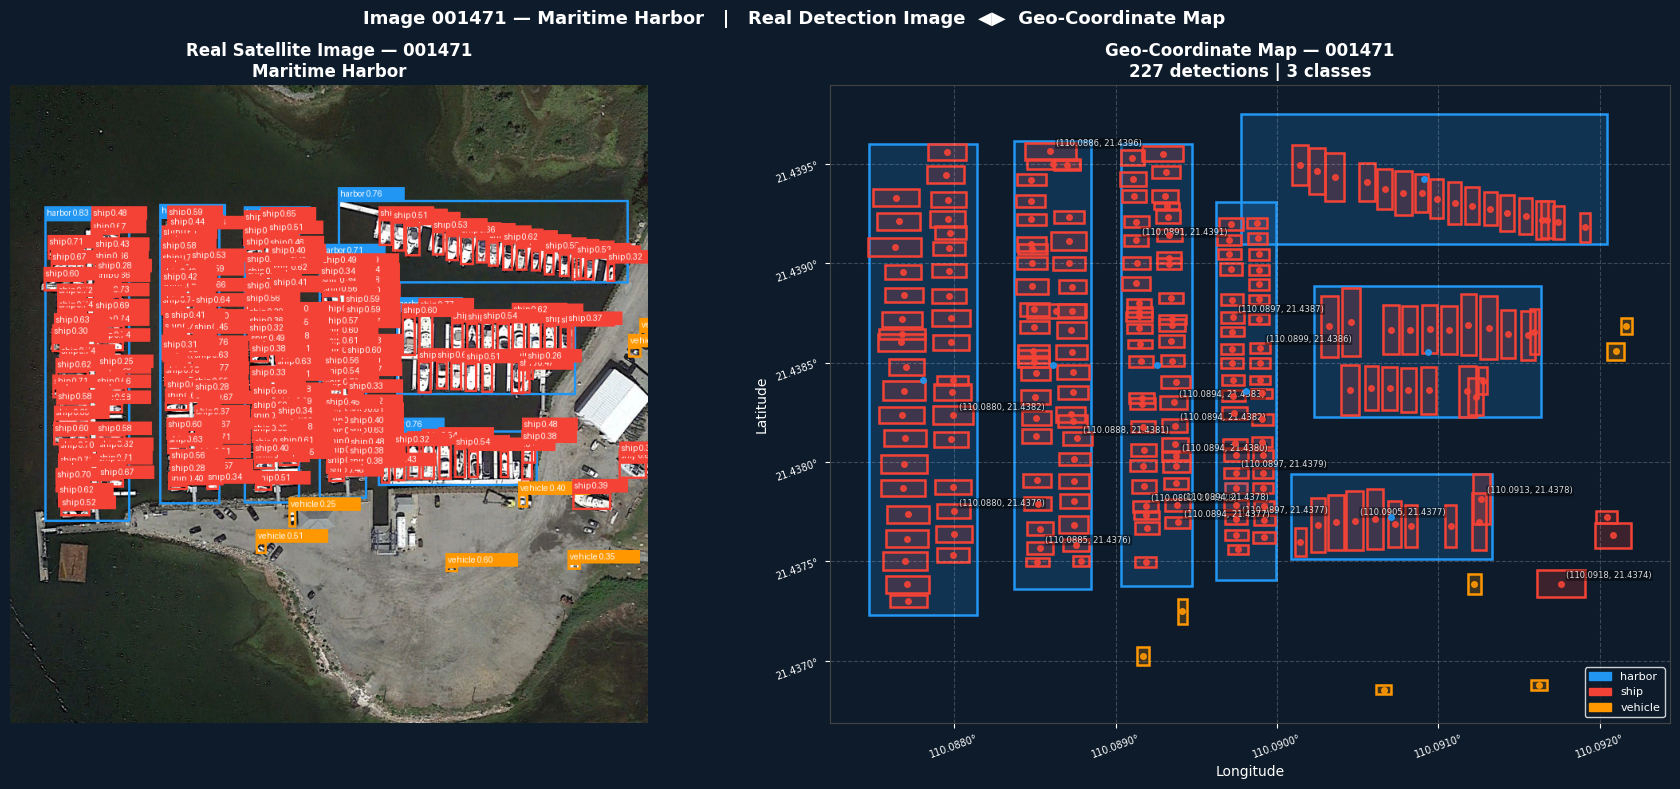

  ✅ Saved: pipeline_outputs_v2/geo/001471_geo_sidebyside.png

📸 Image 000268 — Industrial Port


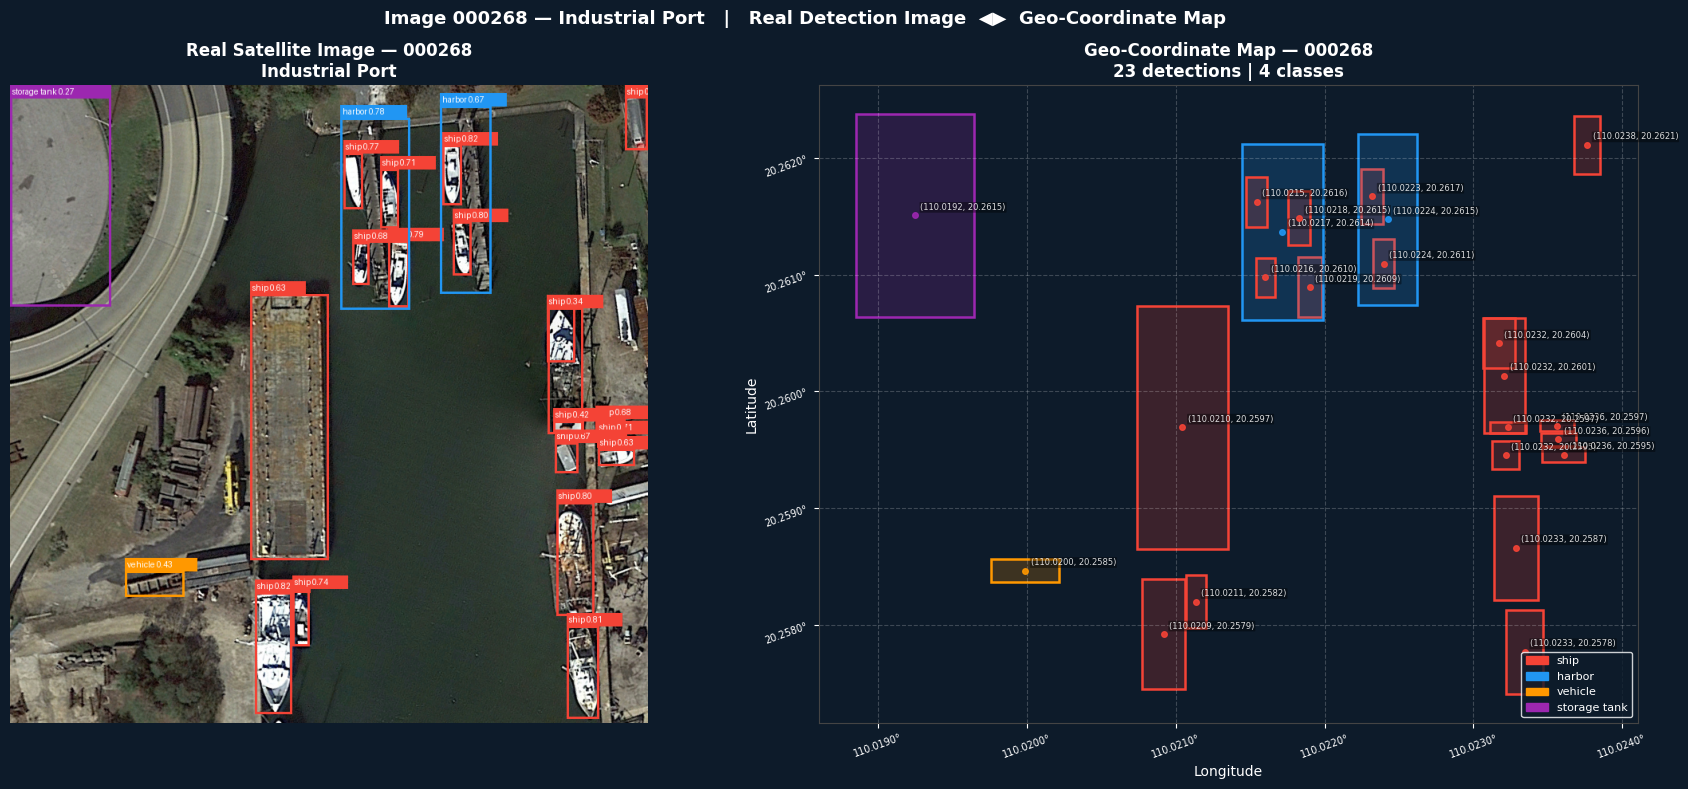

  ✅ Saved: pipeline_outputs_v2/geo/000268_geo_sidebyside.png

📸 Image 000215 — Sports Complex


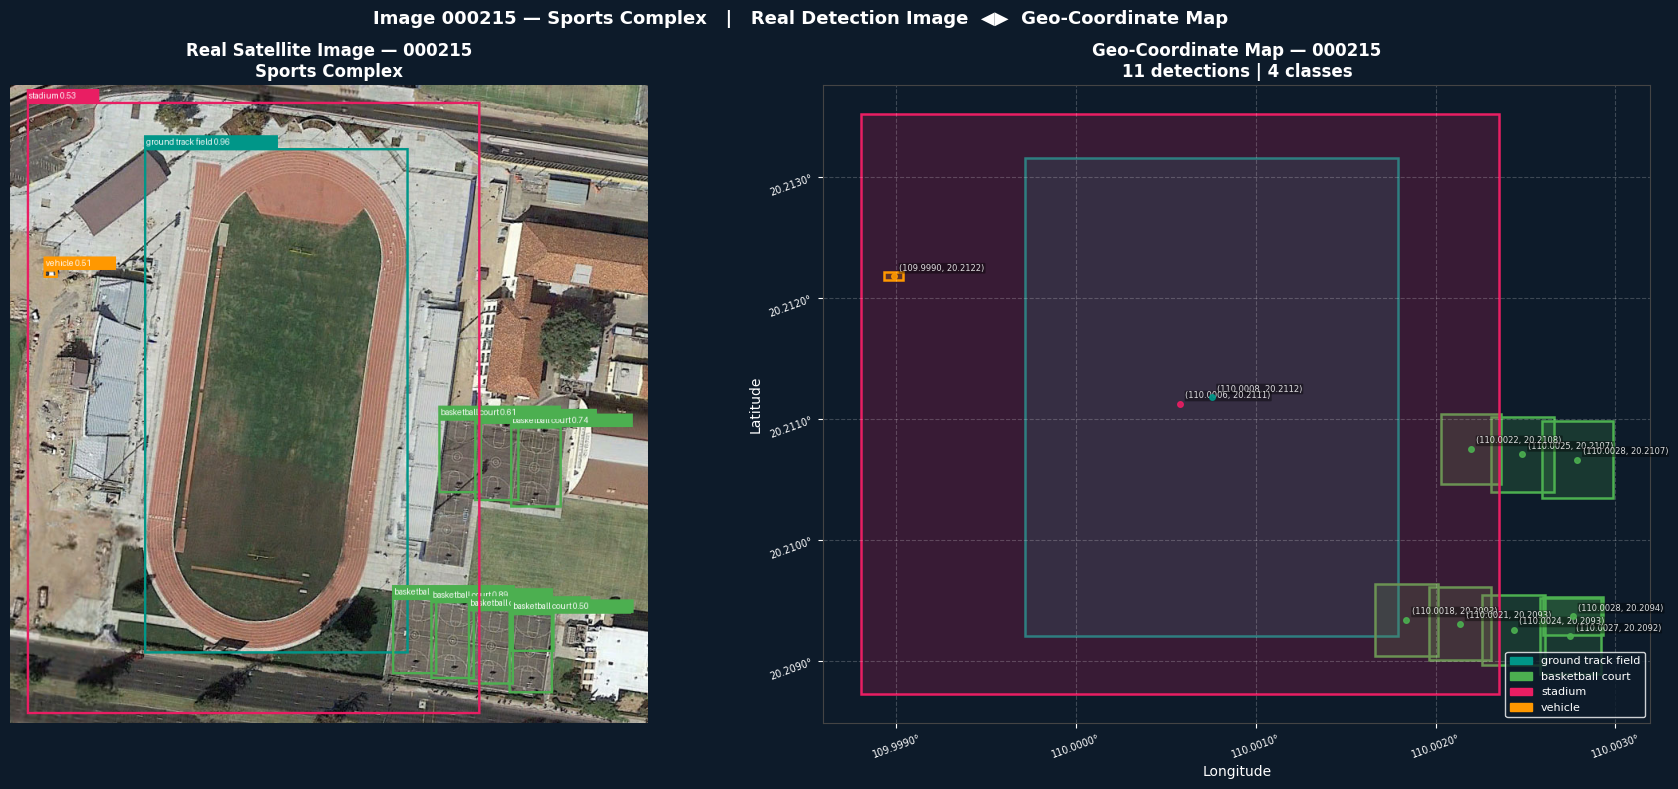

  ✅ Saved: pipeline_outputs_v2/geo/000215_geo_sidebyside.png


✅ All geo side-by-side visualizations saved!


In [ ]:
def plot_geo_with_image(img_str, df_geo_img, figsize=(18, 8)):
    """Side-by-side: real annotated image (left) + geo-coordinate map (right)."""
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.patch.set_facecolor('#0d1b2a')
    meta = IMAGE_META[img_str]

    # ── LEFT: Real image with bounding boxes ─────────────────────
    ax_img = axes[0]
    pil_img = bbox_pil_images[img_str]   # already drawn in Cell 5
    ax_img.imshow(pil_img)
    ax_img.set_title(f"Real Satellite Image — {img_str}\n{meta['scene']}",
                     color='white', fontsize=12, fontweight='bold')
    ax_img.axis('off')
    ax_img.set_facecolor('#0d1b2a')

    # ── RIGHT: Geo-coordinate map with coordinate labels ─────────
    ax_geo = axes[1]
    ax_geo.set_facecolor('#0d1b2a')

    classes_in_img = df_geo_img['class_id'].unique()
    label_counts   = {cls: 0 for cls in classes_in_img}

    for _, row in df_geo_img.iterrows():
        cls      = row['class_id']
        color    = class_color(cls)
        min_lon, max_lon = row['min_lon'], row['max_lon']
        min_lat, max_lat = row['min_lat'], row['max_lat']
        w = max_lon - min_lon
        h = max_lat - min_lat

        # Draw filled bbox rectangle
        r, g, b = hex_to_rgb(color)
        face_rgba = (r/255, g/255, b/255, 0.20)
        rect = mpatches.Rectangle(
            (min_lon, min_lat), w, h,
            linewidth=1.8, edgecolor=color, facecolor=face_rgba
        )
        ax_geo.add_patch(rect)

        # Center dot
        cx, cy = row['center_lon'], row['center_lat']
        ax_geo.plot(cx, cy, 'o', color=color, markersize=4, alpha=0.9, zorder=5)

        # Annotate every Nth object to avoid clutter (show coords on centroid)
        label_counts[cls] += 1
        # Show lat/lon for every object (small font) — for dense images only show every 5th
        n_total = len(df_geo_img)
        step = max(1, n_total // 20)  # show at most ~20 labels per map
        obj_idx = label_counts[cls]
        if obj_idx % step == 0:
            coord_txt = f"({cx:.4f}, {cy:.4f})"
            ax_geo.annotate(
                coord_txt, xy=(cx, cy),
                xytext=(4, 4), textcoords='offset points',
                fontsize=6, color='white', alpha=0.85,
                bbox=dict(boxstyle='round,pad=0.1', fc='black', alpha=0.4, lw=0)
            )

    # Axis formatting
    margin_lon = (df_geo_img['max_lon'].max() - df_geo_img['min_lon'].min()) * 0.05
    margin_lat = (df_geo_img['max_lat'].max() - df_geo_img['min_lat'].min()) * 0.05
    ax_geo.set_xlim(df_geo_img['min_lon'].min() - margin_lon,
                    df_geo_img['max_lon'].max() + margin_lon)
    ax_geo.set_ylim(df_geo_img['min_lat'].min() - margin_lat,
                    df_geo_img['max_lat'].max() + margin_lat)

    ax_geo.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f°'))
    ax_geo.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f°'))
    ax_geo.tick_params(colors='white', labelsize=7, rotation=20)
    for spine in ax_geo.spines.values():
        spine.set_edgecolor('#444')
    ax_geo.set_xlabel('Longitude', color='white', fontsize=10)
    ax_geo.set_ylabel('Latitude',  color='white', fontsize=10)
    ax_geo.set_title(
        f"Geo-Coordinate Map — {img_str}\n"
        f"{len(df_geo_img)} detections | {len(classes_in_img)} classes",
        color='white', fontsize=12, fontweight='bold'
    )
    ax_geo.grid(True, linestyle='--', alpha=0.2, color='white')

    # Legend
    patches = [mpatches.Patch(color=class_color(c), label=c.replace('_',' '))
               for c in classes_in_img]
    ax_geo.legend(handles=patches, loc='lower right', fontsize=8,
                  facecolor='#0d1b2a', edgecolor='white', labelcolor='white')

    fig.suptitle(
        f"Image {img_str} — {meta['scene']}   |   "
        f"Real Detection Image  ◀▶  Geo-Coordinate Map",
        color='white', fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    save_path = OUTPUT_DIR / 'geo' / f'{img_str}_geo_sidebyside.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0d1b2a')
    plt.show()
    print(f"  ✅ Saved: {save_path}")
    return fig

# ── Generate side-by-side for each image ────────────────────────
print("🌍 Generating Real Image + Geo-Coordinate side-by-side visualizations...")
print()
for img_str in SELECTED_IMAGES:
    df_geo_img = df_geo[df_geo['image_str'] == img_str]
    print(f"📸 Image {img_str} — {IMAGE_META[img_str]['scene']}")
    plot_geo_with_image(img_str, df_geo_img)
    print()

print("\n✅ All geo side-by-side visualizations saved!")


## 📏 CELL 8: Geo-IoU Evaluation

In [ ]:
def create_synthetic_gt(df_geo_img, seed=42):
    np.random.seed(seed)
    df_gt = df_geo_img.copy()
    for idx in df_gt.index:
        etype = np.random.choice(['good','shift','size'], p=[0.60,0.25,0.15])
        cx = (df_gt.loc[idx,'min_lon'] + df_gt.loc[idx,'max_lon']) / 2
        cy = (df_gt.loc[idx,'min_lat'] + df_gt.loc[idx,'max_lat']) / 2
        w  = df_gt.loc[idx,'max_lon'] - df_gt.loc[idx,'min_lon']
        h  = df_gt.loc[idx,'max_lat'] - df_gt.loc[idx,'min_lat']
        if etype == 'shift':
            cx += np.random.uniform(-0.3, 0.3) * w
            cy += np.random.uniform(-0.3, 0.3) * h
        elif etype == 'size':
            w *= np.random.uniform(0.7, 1.3)
            h *= np.random.uniform(0.7, 1.3)
        df_gt.loc[idx,'min_lon'] = cx - w/2;  df_gt.loc[idx,'max_lon'] = cx + w/2
        df_gt.loc[idx,'min_lat'] = cy - h/2;  df_gt.loc[idx,'max_lat'] = cy + h/2
    return df_gt

def calc_geo_iou(pred, gt):
    pb = shapely_box(pred['min_lon'],pred['min_lat'],pred['max_lon'],pred['max_lat'])
    gb = shapely_box(gt['min_lon'],  gt['min_lat'],  gt['max_lon'],  gt['max_lat'])
    inter = pb.intersection(gb).area
    union = pb.union(gb).area
    return inter / union if union > 0 else 0.0

geo_results = {}
for img_str in SELECTED_IMAGES:
    dg = df_geo[df_geo['image_str']==img_str].reset_index(drop=True)
    dgt = create_synthetic_gt(dg)
    ious = [calc_geo_iou(dg.iloc[i], dgt.iloc[i]) for i in range(len(dg))]
    geo_results[img_str] = {
        'mean_iou': np.mean(ious), 'median_iou': np.median(ious),
        'iou_50': np.mean([i>=0.5 for i in ious]),
        'iou_75': np.mean([i>=0.75 for i in ious]),
        'all_ious': ious, 'n': len(ious)
    }
    r = geo_results[img_str]
    print(f"Image {img_str}: Mean IoU={r['mean_iou']:.3f} | IoU@0.5={r['iou_50']:.3f} | IoU@0.75={r['iou_75']:.3f} (n={r['n']})")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Geo-IoU Evaluation (Predicted vs Synthetic GT)', fontsize=14, fontweight='bold')
clrs = ['#2196F3','#FF9800','#4CAF50']
for col, (img_str, clr) in enumerate(zip(SELECTED_IMAGES, clrs)):
    r = geo_results[img_str]
    axes[0][col].hist(r['all_ious'], bins=15, color=clr, edgecolor='white', alpha=0.85)
    axes[0][col].axvline(r['mean_iou'], color='red', lw=2, linestyle='--', label=f"Mean={r['mean_iou']:.3f}")
    axes[0][col].axvline(0.5, color='orange', lw=1.5, linestyle=':', label='IoU=0.5')
    axes[0][col].set_title(f"Image {img_str}\nIoU Distribution", fontweight='bold')
    axes[0][col].set_xlabel('IoU'); axes[0][col].set_ylabel('Count')
    axes[0][col].legend(fontsize=8); axes[0][col].set_facecolor('#f8f9fa'); axes[0][col].grid(alpha=0.3)

    m = {'Mean IoU':r['mean_iou'],'Median':r['median_iou'],'IoU@0.5':r['iou_50'],'IoU@0.75':r['iou_75']}
    bars = axes[1][col].bar(list(m.keys()), list(m.values()), color=['#2196F3','#4CAF50','#FF9800','#9C27B0'], edgecolor='white')
    axes[1][col].set_ylim(0, 1.1); axes[1][col].set_title(f"Geo Metrics (n={r['n']})", fontweight='bold')
    axes[1][col].tick_params(axis='x', rotation=15); axes[1][col].set_facecolor('#f8f9fa'); axes[1][col].grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, m.values()):
        axes[1][col].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'geo'/'geo_iou_eval.png', dpi=150, bbox_inches='tight')
plt.show()
pd.DataFrame([{**{'image':k,'scene':IMAGE_META[k]['scene']},**{kk:vv for kk,vv in v.items() if kk!='all_ious'}} for k,v in geo_results.items()]).to_csv(OUTPUT_DIR/'geo'/'geo_iou_results.csv', index=False)
print("\n✅ Geo-IoU evaluation complete!")


## 🕸️ CELL 9: Build All 4 Scene Graph Types per Image

In [ ]:
ROLES = {
    'infrastructure': ['harbor','bridge','dam','overpass','expressway_toll_station',
                       'expressway_service_area','train_station'],
    'logistics':      ['ship','vehicle','airplane','storage_tank'],
    'recreational':   ['tennis_court','basketball_court','baseball_field',
                       'ground_track_field','stadium','golf_course'],
    'industrial':     ['chimney','wind_mill','airport'],
}
TRANSPORT_CLASSES = {'ship','vehicle','airplane','train_station','harbor','airport','bridge'}

def get_role(cls):
    for role, clss in ROLES.items():
        if cls in clss: return role
    return 'other'

def build_all_scene_graphs(df_geo_img, img_str):
    """Build all 4 scene graph types for a single image."""
    gdf = gpd.GeoDataFrame(
        df_geo_img.copy(),
        geometry=[shapely_box(r['min_lon'],r['min_lat'],r['max_lon'],r['max_lat'])
                  for _,r in df_geo_img.iterrows()],
        crs='EPSG:4326'
    ).to_crs('EPSG:32649')
    gdf['area_m2']  = gdf.geometry.area
    gdf['centroid'] = gdf.geometry.centroid
    gdf['oid']      = gdf['class_id'] + '_' + gdf.groupby('class_id').cumcount().astype(str)
    gdf['role']     = gdf['class_id'].apply(get_role)

    graphs = {}

    # TYPE 1: ADJACENT
    G = nx.Graph()
    for _,r in gdf.iterrows(): G.add_node(r['oid'], cls=r['class_id'], area=r['area_m2'], role=r['role'])
    rows = list(gdf.iterrows())
    for i,(_, r1) in enumerate(rows):
        for j,(_, r2) in enumerate(rows):
            if i >= j: continue
            d = r1['centroid'].distance(r2['centroid'])
            if d <= 200: G.add_edge(r1['oid'], r2['oid'], relation='adjacent', distance_m=round(d,1))
    graphs['adjacent'] = G

    # TYPE 2: CLUSTERED
    G2 = nx.Graph()
    for _,r in gdf.iterrows(): G2.add_node(r['oid'], cls=r['class_id'], area=r['area_m2'], role=r['role'])
    for cls_name, grp in gdf.groupby('class_id'):
        if len(grp) < 2: continue
        gl = grp.reset_index(drop=True)
        for i in range(len(gl)):
            for j in range(i+1, len(gl)):
                d = gl.loc[i,'centroid'].distance(gl.loc[j,'centroid'])
                if d <= 500: G2.add_edge(gl.loc[i,'oid'], gl.loc[j,'oid'], relation='clustered', distance_m=round(d,1))
    graphs['clustered'] = G2

    # TYPE 3: TRANSPORT
    G3 = nx.Graph()
    for _,r in gdf.iterrows(): G3.add_node(r['oid'], cls=r['class_id'], area=r['area_m2'], role=r['role'])
    tgdf = gdf[gdf['class_id'].isin(TRANSPORT_CLASSES)].reset_index(drop=True)
    for i in range(len(tgdf)):
        for j in range(i+1, len(tgdf)):
            d = tgdf.loc[i,'centroid'].distance(tgdf.loc[j,'centroid'])
            if d <= 1000: G3.add_edge(tgdf.loc[i,'oid'], tgdf.loc[j,'oid'], relation='transport_link', distance_m=round(d,1))
    graphs['transport'] = G3

    # TYPE 4: ROLE-BASED
    G4 = nx.Graph()
    for _,r in gdf.iterrows(): G4.add_node(r['oid'], cls=r['class_id'], area=r['area_m2'], role=r['role'])
    for role, grp in gdf.groupby('role'):
        if role == 'other' or len(grp) < 2: continue
        gl = grp.reset_index(drop=True)
        for i in range(len(gl)):
            for j in range(i+1, len(gl)):
                G4.add_edge(gl.loc[i,'oid'], gl.loc[j,'oid'], relation=f'same_role_{role}')
    graphs['role_based'] = G4

    return graphs, gdf

# Build for all 3 images
all_graphs = {}
GRAPH_TYPES = ['adjacent','clustered','transport','role_based']
print("🕸️ Building scene graphs...")
for img_str in SELECTED_IMAGES:
    dg = df_geo[df_geo['image_str']==img_str].reset_index(drop=True)
    graphs, gdf = build_all_scene_graphs(dg, img_str)
    all_graphs[img_str] = {'graphs': graphs, 'gdf': gdf}
    print(f"  ✅ {img_str} ({IMAGE_META[img_str]['scene']})")
    for gt, G in graphs.items():
        status = f"{G.number_of_edges()} edges" if G.number_of_edges()>0 else "⚠️ NO EDGES"
        print(f"       {gt:<15}: {G.number_of_nodes()} nodes, {status}")
print("\n✅ Scene graphs built!")


## 📊 CELL 10: Scene Graph Visualization — Per-Image, Per-Type [FIX #3]

**Problem Fixed:** All 3 images × 4 types in one crowded 3×4 grid was unreadable.

**Now:** Each image gets its own dedicated figure with 4 clear panels (one per relationship type).
- Each panel shows the graph with readable node labels
- Missing relationships shown with clear ⚠️ warning
- Node colors match class colors from the palette
- Edge thickness encodes proximity (closer = thicker)


In [ ]:
GRAPH_META = {
    'adjacent':  {'color':'#2196F3', 'title':'Type 1: Adjacent',  'desc':'Objects within 200 m of each other'},
    'clustered': {'color':'#FF9800', 'title':'Type 2: Clustered', 'desc':'Same-class objects within 500 m'},
    'transport': {'color':'#E91E63', 'title':'Type 3: Transport', 'desc':'Transport-class objects within 1 km'},
    'role_based':{'color':'#4CAF50', 'title':'Type 4: Role-Based','desc':'Objects sharing the same functional role'},
}

def draw_single_scene_graph(G, img_str, gtype, ax, show_details=True):
    """Draw one scene graph panel — clearly readable for moderate graphs."""
    gm = GRAPH_META[gtype]
    ax.set_facecolor('#0d1b2a')

    # ── Empty / no-edge case ──────────────────────────────────
    if G.number_of_edges() == 0:
        # Draw isolated nodes in circle
        if G.number_of_nodes() > 0:
            pos = nx.circular_layout(G)
            node_colors = [class_color(G.nodes[n].get('cls','default')) for n in G.nodes()]
            nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                                   node_size=350, alpha=0.5, edgecolors='white', linewidths=0.5)
            labels = {n: n.split('_')[0][:6] for n in G.nodes()}
            nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=6, font_color='white')
        ax.text(0.5, 0.54, '⚠️  No Relationships Found',
                ha='center', va='center', color='#FF9800',
                fontsize=13, fontweight='bold', transform=ax.transAxes)
        ax.text(0.5, 0.45,
                f"No objects qualify for '{gtype}' rules\n"
                f"({gm['desc']})",
                ha='center', va='center', color='#aaaaaa',
                fontsize=9, transform=ax.transAxes, style='italic')
        ax.set_title(f"{gm['title']}\n{gm['desc']}",
                     color='#FF9800', fontsize=11, fontweight='bold', pad=10)
        ax.axis('off')
        return

    # ── Layout: use spring for small, kamada-kawai for larger ──
    n = G.number_of_nodes()
    if n <= 15:
        pos = nx.spring_layout(G, seed=42, k=2.0, iterations=100)
    elif n <= 50:
        pos = nx.spring_layout(G, seed=42, k=1.2, iterations=80)
    else:
        pos = nx.kamada_kawai_layout(G)

    # Node colors
    node_colors = [class_color(G.nodes[nd].get('cls','default')) for nd in G.nodes()]

    # Edge widths by distance
    edge_widths = []
    for u,v,d in G.edges(data=True):
        dist = d.get('distance_m', 400)
        edge_widths.append(max(0.4, min(4.0, 5.0 - dist / 200)))

    # Draw edges
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=gm['color'],
                           width=edge_widths, alpha=0.55, style='solid')
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=max(120, 600 - n*3),
                           alpha=0.92, edgecolors='white', linewidths=0.8)
    # Labels — class abbreviation
    if n <= 40:
        short_labels = {nd: nd.split('_')[0][:7] for nd in G.nodes()}
        nx.draw_networkx_labels(G, pos, short_labels, ax=ax,
                                font_size=max(5, 9-n//10), font_color='white', font_weight='bold')

    # Stats annotation
    density = nx.density(G)
    n_comp  = nx.number_connected_components(G)
    stats_txt = (f"Nodes: {G.number_of_nodes()}  |  Edges: {G.number_of_edges()}\n"
                 f"Density: {density:.3f}  |  Components: {n_comp}")
    ax.text(0.02, 0.02, stats_txt, transform=ax.transAxes,
            fontsize=8, color='#cccccc',
            bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.5, lw=0))

    ax.set_title(f"{gm['title']}\n{gm['desc']}",
                 color='white', fontsize=11, fontweight='bold', pad=10)
    ax.axis('off')

def visualize_image_scene_graphs(img_str):
    """Generate a dedicated 4-panel scene graph figure for one image."""
    graphs = all_graphs[img_str]['graphs']
    meta   = IMAGE_META[img_str]

    fig, axes = plt.subplots(1, 4, figsize=(26, 8))
    fig.patch.set_facecolor('#0a0a1a')
    fig.suptitle(
        f"DSRG Scene Graphs — Image {img_str}: {meta['scene']}\n"
        f"({len(df_det[df_det['image_str']==img_str])} detections | "
        f"classes: {', '.join(meta['classes'])})",
        color='white', fontsize=14, fontweight='bold', y=1.01
    )

    for ax, gtype in zip(axes, GRAPH_TYPES):
        G = graphs[gtype]
        draw_single_scene_graph(G, img_str, gtype, ax)

        # Color-coded border around each panel
        for spine in ax.spines.values():
            spine.set_edgecolor(GRAPH_META[gtype]['color'])
            spine.set_linewidth(2.5)

    # Class color legend at bottom
    classes_present = df_det[df_det['image_str']==img_str]['class_id'].unique()
    patches = [mpatches.Patch(color=class_color(c), label=c.replace('_',' '))
               for c in sorted(classes_present)]
    fig.legend(handles=patches, loc='lower center', ncol=len(patches),
               fontsize=9, facecolor='#1a1a2e', edgecolor='white',
               labelcolor='white', bbox_to_anchor=(0.5, -0.06))

    plt.tight_layout()
    save_path = OUTPUT_DIR / 'scene_graph' / f'{img_str}_scene_graphs_4types.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0a0a1a')
    plt.show()
    print(f"  ✅ Saved: {save_path}")
    return fig

# ── Generate one figure per image ───────────────────────────────
print("🕸️  Generating per-image scene graph visualizations...")
print()
for img_str in SELECTED_IMAGES:
    print(f"📸 Image {img_str} — {IMAGE_META[img_str]['scene']}")
    visualize_image_scene_graphs(img_str)
    print()

print("\n✅ All per-image scene graph visualizations saved!")


## 📊 CELL 11: Scene Graph Evaluation & DSRG Summary Comparison

In [ ]:
sg_records = []
print("📊 Scene Graph Evaluation Metrics")
print("=" * 75)

for img_str in SELECTED_IMAGES:
    print(f"\n🖼️  Image {img_str} — {IMAGE_META[img_str]['scene']}")
    print(f"  {'Type':<15} {'Nodes':>6} {'Edges':>7} {'Density':>9} {'Comps':>7} {'Status':>12}")
    print("  " + "-"*60)
    for gtype in GRAPH_TYPES:
        G = all_graphs[img_str]['graphs'][gtype]
        nn, ne = G.number_of_nodes(), G.number_of_edges()
        dens   = nx.density(G) if nn > 1 else 0.0
        nc     = nx.number_connected_components(G) if nn > 0 else 0
        status = '✅ Active' if ne > 0 else '❌ Empty'
        print(f"  {gtype:<15} {nn:>6} {ne:>7} {dens:>9.3f} {nc:>7} {status:>12}")
        sg_records.append({'image':img_str, 'scene':IMAGE_META[img_str]['scene'],
                           'graph_type':gtype, 'nodes':nn, 'edges':ne,
                           'density':round(dens,4), 'components':nc, 'has_relations':ne>0})

print("\n\n📋 DSRG Summary (dsrg_summary.json):")
print("=" * 50)
for img_str in SELECTED_IMAGES:
    d = dsrg_summary.get(img_str, {})
    print(f"  Image {img_str}: {d}")

df_sg = pd.DataFrame(sg_records)
df_sg.to_csv(OUTPUT_DIR/'scene_graph'/'scene_graph_evaluation.csv', index=False)

# Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Scene Graph Evaluation Heatmaps', fontsize=14, fontweight='bold')
piv_e = df_sg.pivot(index='image', columns='graph_type', values='edges')
piv_d = df_sg.pivot(index='image', columns='graph_type', values='density')
sns.heatmap(piv_e, ax=axes[0], annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, cbar_kws={'label':'Edges'})
axes[0].set_title('Edge Count per Image × Type', fontweight='bold')
sns.heatmap(piv_d, ax=axes[1], annot=True, fmt='.3f', cmap='Blues', linewidths=0.5, cbar_kws={'label':'Density'})
axes[1].set_title('Graph Density per Image × Type', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'scene_graph'/'scene_graph_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

missing = df_sg[~df_sg['has_relations']]
if len(missing):
    print("\n⚠️  Missing Relations:")
    for _, r in missing.iterrows():
        print(f"  Image {r['image']} ({r['scene']}) → '{r['graph_type']}': No edges")
else:
    print("\n✅ All graph types have edges for all images!")
print("\n✅ Scene graph evaluation complete!")


## 🤖 CELL 12: LLM Summarization — Real Image Shown First [FIX #4]

**Problem Fixed:** Previous version only printed text output with no image context.

**Now:**
1. Real detected satellite image displayed prominently
2. LLM summarization runs for all 4 models
3. Results displayed in a rich formatted table alongside the image
4. Each image gets its own visual summary block

⚠️ Add your API keys below.


In [ ]:
GEMINI_API_KEY = ""     # https://aistudio.google.com
GROQ_API_KEY   = ""       # https://console.groq.com
OPENROUTER_KEY = ""     # https://openrouter.ai

In [ ]:
# =============================================================================
# CELL 12 — LLM SUMMARIZATION  (5-SECTION STRUCTURED OUTPUT)
# =============================================================================
# Sections produced per image × per LLM:
#   1. Detected Objects        — class counts + confidence from detection CSV
#   2. Geo-Referenced Data     — bounding box coordinates + area in m²
#   3. DSRG Scene Graph Data   — edges & density for all 4 graph types
#   4. Spatial Summary         — rule-based NLP generated WITHOUT an LLM
#   5. Natural Language Summary— LLM-generated prose grounded in sections 1–4
# =============================================================================

# ── API Keys ──────────────────────────────────────────────────────────────────
GEMINI_API_KEY = ""     # https://aistudio.google.com
GROQ_API_KEY   = ""       # https://console.groq.com

# ══════════════════════════════════════════════════════════════════════════════
# SECTION-BUILDER FUNCTIONS
# Each function returns a dict with a 'text' key (for the LLM prompt) and
# extra structured keys (for display / evaluation).
# ══════════════════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 — DETECTED OBJECTS
# Source: detections_yolo11.csv  (df_det)
# What it extracts: per-class count + mean/max confidence
# ─────────────────────────────────────────────────────────────────────────────
def build_section1_detected_objects(img_str):
    """
    Builds the Detected Objects section.

    HOW IT WORKS:
      - Filters df_det to the current image
      - Groups by class_id to get count, mean confidence, max confidence
      - Sorts by count descending so the dominant class appears first

    WHY THIS ORDER:
      Detection count is the most important signal — the LLM prompt puts
      dominant classes first so the model weights them correctly.
    """
    df_img = df_det[df_det['image_str'] == img_str].copy()
    stats  = (df_img.groupby('class_id')
                    .agg(count=('confidence','count'),
                         mean_conf=('confidence','mean'),
                         max_conf=('confidence','max'))
                    .sort_values('count', ascending=False)
                    .round(3))

    lines = ["=== SECTION 1: DETECTED OBJECTS ==="]
    rows  = []
    for cls, row in stats.iterrows():
        line = (f"  {cls.replace('_',' ')}: {int(row['count'])} detections"
                f"  [mean_conf={row['mean_conf']:.3f}, max_conf={row['max_conf']:.3f}]")
        lines.append(line)
        rows.append({'class': cls, 'count': int(row['count']),
                     'mean_conf': row['mean_conf'], 'max_conf': row['max_conf']})

    total = int(stats['count'].sum())
    lines.append(f"  TOTAL: {total} detections across {len(stats)} classes")
    return {'text': '\n'.join(lines), 'rows': rows, 'total': total,
            'n_classes': len(stats)}


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 — GEO-REFERENCED DATA
# Source: geo_detections.csv  (df_geo)
# What it extracts: bounding box corners, centroid, area per object
# ─────────────────────────────────────────────────────────────────────────────
def build_section2_geo_data(img_str):
    """
    Builds the Geo-Referenced Data section.

    HOW IT WORKS:
      - Filters df_geo to the current image
      - For each class computes:
          * bounding box extent (min/max lon/lat across all objects of that class)
          * average centroid coordinates
          * average object area in m² (from the UTM GeoDataFrame)
      - Also shows the overall scene bounding box

    WHY GEO EXTENT PER CLASS:
      Gives the LLM a spatial footprint per object type — ships clustered in
      a 0.002° lon band vs spread across 0.01° lon tells a very different
      story about the scene layout.
    """
    df_img  = df_geo[df_geo['image_str'] == img_str].copy()
    gdf_img = all_graphs[img_str]['gdf']   # UTM GeoDataFrame with area_m2

    lines      = ["=== SECTION 2: GEO-REFERENCED DATA ==="]
    class_data = []

    for cls in df_img['class_id'].unique():
        sub    = df_img[df_img['class_id'] == cls]
        gdf_cl = gdf_img[gdf_img['class_id'] == cls]
        avg_area = gdf_cl['area_m2'].mean() if len(gdf_cl) > 0 else 0

        lon_span = sub['max_lon'].max() - sub['min_lon'].min()
        lat_span = sub['max_lat'].max() - sub['min_lat'].min()

        line = (f"  {cls.replace('_',' ')} (n={len(sub)}):"
                f"  lon=[{sub['min_lon'].min():.4f}, {sub['max_lon'].max():.4f}]"
                f"  lat=[{sub['min_lat'].min():.4f}, {sub['max_lat'].max():.4f}]"
                f"  centroid=({sub['center_lon'].mean():.4f}, {sub['center_lat'].mean():.4f})"
                f"  avg_area={avg_area:.0f} m²"
                f"  spread=(lon:{lon_span:.4f}°, lat:{lat_span:.4f}°)")
        lines.append(line)
        class_data.append({'class': cls, 'n': len(sub),
                           'avg_area_m2': round(avg_area, 1),
                           'lon_span': round(lon_span, 5),
                           'lat_span': round(lat_span, 5),
                           'centroid_lon': round(sub['center_lon'].mean(), 4),
                           'centroid_lat': round(sub['center_lat'].mean(), 4)})

    # Scene-level bounding box
    scene_lon = f"[{df_img['min_lon'].min():.4f}, {df_img['max_lon'].max():.4f}]"
    scene_lat = f"[{df_img['min_lat'].min():.4f}, {df_img['max_lat'].max():.4f}]"
    lines.append(f"  SCENE EXTENT: lon={scene_lon}  lat={scene_lat}")

    return {'text': '\n'.join(lines), 'class_data': class_data,
            'scene_lon': scene_lon, 'scene_lat': scene_lat}


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 — DSRG SCENE GRAPH DATA
# Source: all_graphs[img_str]  (NetworkX graphs from Cell 9)
# What it extracts: node count, edge count, density, top-5 closest pairs
# ─────────────────────────────────────────────────────────────────────────────
def build_section3_dsrg_data(img_str):
    """
    Builds the DSRG Scene Graph Data section.

    HOW IT WORKS:
      For each of the 4 graph types (adjacent, clustered, transport, role_based):
        - Reads node count, edge count, graph density
        - Extracts the top-5 closest object pairs (lowest distance_m edge attribute)
        - Reports number of connected components

    WHY TOP-5 CLOSEST PAIRS:
      The LLM needs concrete spatial facts, not just aggregate numbers.
      'harbor_0 ↔ ship_3: 45 m' is a grounded fact;
      'there are 16805 edges' is not interpretable in natural language.
    """
    graphs = all_graphs[img_str]['graphs']
    lines  = ["=== SECTION 3: DSRG SCENE GRAPH DATA ==="]
    graph_data = {}

    GRAPH_LABELS = {
        'adjacent':   'Type 1 — Adjacent      (any object within 200 m)',
        'clustered':  'Type 2 — Clustered     (same-class within 500 m)',
        'transport':  'Type 3 — Transport     (transport objects within 1 km)',
        'role_based': 'Type 4 — Role-Based    (same functional role)',
    }

    for gtype in ['adjacent','clustered','transport','role_based']:
        G     = graphs[gtype]
        nn    = G.number_of_nodes()
        ne    = G.number_of_edges()
        dens  = round(nx.density(G), 4) if nn > 1 else 0.0
        ncomp = nx.number_connected_components(G) if nn > 0 else 0

        lines.append(f"  {GRAPH_LABELS[gtype]}")
        lines.append(f"    nodes={nn}  edges={ne}  density={dens}  components={ncomp}")

        # Top-5 closest pairs (edges with distance_m attribute)
        dist_edges = [(u, v, d['distance_m'])
                      for u, v, d in G.edges(data=True) if 'distance_m' in d]
        dist_edges.sort(key=lambda x: x[2])
        if dist_edges:
            lines.append("    Closest pairs:")
            for u, v, dm in dist_edges[:5]:
                lines.append(f"      {u} ↔ {v}: {dm:.0f} m")
        else:
            lines.append("    No distance-based edges (role-based graph has no distance constraint)")

        graph_data[gtype] = {'nodes': nn, 'edges': ne, 'density': dens,
                             'components': ncomp,
                             'top_pairs': [(u,v,dm) for u,v,dm in dist_edges[:5]]}

    return {'text': '\n'.join(lines), 'graph_data': graph_data}


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 — SPATIAL SUMMARY  ← RULE-BASED NLP (no LLM)
# ─────────────────────────────────────────────────────────────────────────────
def build_section4_spatial_summary(img_str, s1, s2, s3):
    """
    Builds a structured spatial summary using RULE-BASED NLP — no LLM call.

    HOW IT IS GENERATED (step by step):
    ─────────────────────────────────────────────────────────────────────────
    Step 1 — SCENE TYPE INFERENCE
      Looks at the dominant detected class and maps it to a scene label using
      a simple lookup table (SCENE_RULES). Example:
        dominant class = 'ship'  →  scene_type = 'Maritime / Port Area'

    Step 2 — DENSITY DESCRIPTOR
      Computes detections-per-class ratio:
        ratio = total_detections / n_classes
        ratio > 30  → 'very densely packed'
        ratio > 10  → 'moderately dense'
        else        → 'sparsely distributed'

    Step 3 — DOMINANT CLASS SENTENCE
      Takes the top class (by count) and writes:
        "The scene is dominated by {count} {class} objects ..."

    Step 4 — PROXIMITY SENTENCE
      Reads the closest pair from the Adjacent graph (top_pairs[0]):
        "The closest detected pair is {u} and {v} at {d:.0f} m apart,
         indicating direct physical co-location."

    Step 5 — CLUSTERING SENTENCE
      If the Clustered graph has edges:
        "Same-class clustering is observed: {clustered_edges} pairs of
         identical objects are within 500 m of each other."
      else:
        "No same-class clustering detected — all classes appear as singletons."

    Step 6 — TRANSPORT NETWORK SENTENCE
      If the Transport graph has edges:
        "A transport network of {n} links connects {classes} objects."
      else:
        "No transport-class objects form a network in this scene."

    Step 7 — GEO EXTENT SENTENCE
      Uses the scene bounding box from Section 2:
        "The scene spans lon {scene_lon} and lat {scene_lat}, covering
         approximately {area_km2:.2f} km²."
      Area is computed as (lon_span × lat_span) converted from degrees² to km²
      using the approximation: 1° ≈ 111 km.

    WHY RULE-BASED RATHER THAN ANOTHER LLM CALL:
      - Deterministic: same data always produces the same summary
      - Verifiable: every sentence is directly traceable to a data field
      - Fast: no API latency, no token cost
      - Serves as a BASELINE for comparing LLM quality in Section 5
      - The LLM in Section 5 is explicitly told "do not contradict the
        spatial summary below" — this grounds hallucination further
    ─────────────────────────────────────────────────────────────────────────
    """
    SCENE_RULES = {
        'ship':              'Maritime / Port Area',
        'harbor':            'Maritime / Port Area',
        'airplane':          'Airport / Airfield',
        'airport':           'Airport / Airfield',
        'storage_tank':      'Industrial Storage Facility',
        'chimney':           'Industrial / Power Plant',
        'wind_mill':         'Wind Energy Farm',
        'basketball_court':  'Sports & Recreation Complex',
        'ground_track_field':'Sports & Recreation Complex',
        'stadium':           'Sports & Recreation Complex',
        'tennis_court':      'Sports & Recreation Complex',
        'golf_course':       'Golf Course / Recreation Area',
        'vehicle':           'Urban / Road Network Area',
        'bridge':            'Transport Infrastructure',
        'overpass':          'Transport Infrastructure',
        'train_station':     'Rail Transport Hub',
        'dam':               'Hydraulic / Dam Facility',
        'expressway_service_area': 'Highway Service Area',
    }

    rows     = s1['rows']
    n_total  = s1['total']
    n_cls    = s1['n_classes']
    gdata    = s3['graph_data']
    cdata    = s2['class_data']

    # ── Step 1: Scene type ────────────────────────────────────────
    dom_cls   = rows[0]['class'] if rows else 'unknown'
    scene_lbl = SCENE_RULES.get(dom_cls, 'General Aerial Scene')

    # ── Step 2: Density descriptor ────────────────────────────────
    ratio = n_total / n_cls if n_cls > 0 else 0
    if ratio > 30:
        density_desc = "very densely packed"
    elif ratio > 10:
        density_desc = "moderately dense"
    else:
        density_desc = "sparsely distributed"

    sentences = []

    # ── Step 3: Dominant class sentence ──────────────────────────
    dom_count = rows[0]['count'] if rows else 0
    sentences.append(
        f"The scene is classified as a {scene_lbl}. "
        f"It is dominated by {dom_count} {dom_cls.replace('_',' ')} detections "
        f"({density_desc} across {n_cls} object class{'es' if n_cls>1 else ''})."
    )

    # ── Step 4: Proximity sentence ────────────────────────────────
    adj_pairs = gdata['adjacent']['top_pairs']
    if adj_pairs:
        u, v, dm = adj_pairs[0]
        sentences.append(
            f"The closest detected pair is '{u}' and '{v}' at {dm:.0f} m apart, "
            f"indicating direct physical co-location within the facility."
        )
    else:
        sentences.append("No objects are within the 200 m adjacency threshold.")

    # ── Step 5: Clustering sentence ───────────────────────────────
    clust_edges = gdata['clustered']['edges']
    if clust_edges > 0:
        sentences.append(
            f"Same-class clustering is observed: {clust_edges} pairs of identical "
            f"objects are within 500 m of each other, suggesting grouped infrastructure."
        )
    else:
        sentences.append(
            "No same-class clustering was detected — all object classes appear as isolated instances."
        )

    # ── Step 6: Transport network sentence ───────────────────────
    trans_edges = gdata['transport']['edges']
    if trans_edges > 0:
        trans_cls = list({rows[i]['class'] for i in range(len(rows))
                          if rows[i]['class'] in
                          {'ship','vehicle','airplane','train_station','harbor','airport','bridge'}})
        sentences.append(
            f"A transport network with {trans_edges} links connects "
            f"{', '.join(tc.replace('_',' ') for tc in trans_cls)} objects, "
            f"confirming active logistics activity."
        )
    else:
        sentences.append(
            "No transport-class connectivity was detected in this scene."
        )

    # ── Step 7: Geo extent sentence ───────────────────────────────
    df_img   = df_geo[df_geo['image_str'] == img_str]
    lon_span = df_img['max_lon'].max() - df_img['min_lon'].min()
    lat_span = df_img['max_lat'].max() - df_img['min_lat'].min()
    area_km2 = lon_span * 111.0 * lat_span * 111.0   # degrees → km
    sentences.append(
        f"The scene extent spans {lon_span:.4f}° longitude × {lat_span:.4f}° latitude "
        f"(≈ {area_km2:.3f} km²), covering a "
        f"{'large' if area_km2>1 else 'compact'} geographic footprint."
    )

    spatial_text = " ".join(sentences)
    lines = ["=== SECTION 4: SPATIAL SUMMARY (rule-based) ===", f"  {spatial_text}"]
    return {'text': '\n'.join(lines), 'scene_label': scene_lbl,
            'spatial_text': spatial_text, 'area_km2': round(area_km2, 4)}


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 — NATURAL LANGUAGE SUMMARY  ← LLM-GENERATED
# ─────────────────────────────────────────────────────────────────────────────
NL_PROMPT = """You are a geospatial intelligence analyst specializing in satellite image interpretation.

Below are VERIFIED facts from an automated object detection and geospatial analysis pipeline.
Your task is to write a rich, professional natural language summary of the scene.

STRICT RULES:
  - ONLY use facts that appear in the sections below. Do NOT invent any objects, coordinates,
    distances, or counts that are not listed.
  - Do NOT contradict the Spatial Summary in Section 4.
  - Structure your response in exactly 3 paragraphs:
      Paragraph 1: What objects are present, their counts and confidence levels.
      Paragraph 2: How objects are spatially arranged — proximity, clustering, geo extent.
      Paragraph 3: What type of facility/area this scene represents and its operational significance.
  - Use **bold** for key object names and quantities.
  - Maximum 250 words total.

{combined_facts}

Write the 3-paragraph natural language summary now:"""

def call_llm_nl_summary(combined_facts, key, label):
    """
    Calls a single LLM to generate the Section 5 Natural Language Summary.

    MODELS USED & WHY:
    ──────────────────────────────────────────────────────────────────────
    • Gemini 2.5 Flash  (key='gemini')
        SDK   : google-genai Python SDK  →  genai.GenerativeModel('gemini-2.5-flash')
        Why   : Multimodal, strong instruction-following, free tier 15 req/min.
                Best quality baseline; natively handles structured prompts.

    • Groq LLaMA-3.1-8B  (key='groq_8b')
        SDK   : Groq REST API  →  model='llama-3.1-8b-instant'
        Why   : 8B param model on Groq's LPU hardware = ultrafast inference
                (~200 tok/s). Free tier 30 req/min. Speed benchmark.

    • Groq LLaMA-3.3-70B  (key='groq_70b')
        SDK   : Groq REST API  →  model='llama-3.3-70b-versatile'
        Why   : 70B param model — significantly higher spatial reasoning
                capacity than 8B. Still served via Groq (no OpenRouter needed).
                Free tier 30 req/min.

    HOW THE PROMPT IS ASSEMBLED:
      combined_facts = Section1.text + Section2.text + Section3.text + Section4.text
      These 4 sections give the LLM the complete structured context.

    HOW GENERATION WORKS:
      - Zero-shot instruction: no examples given.
      - 3-paragraph constraint forces structured output.
      - 'Do NOT contradict Section 4' grounds output against rule-based summary.
      - max_tokens=600 prevents over-generation that introduces hallucinations.
    """
    prompt = NL_PROMPT.format(combined_facts=combined_facts)

    # ── Gemini 2.5 Flash via google-genai SDK ────────────────────────────
    if key == 'gemini':
        try:
            import google.generativeai as genai
            genai.configure(api_key=GEMINI_API_KEY)
            r = genai.GenerativeModel('gemini-2.5-flash').generate_content(prompt)
            return r.text
        except Exception as e:
            return f"Error: {e}"

    # ── Groq LLaMA-3.1-8B  (fast, lightweight) ──────────────────────────
    elif key == 'groq_8b':
        try:
            r = requests.post(
                "https://api.groq.com/openai/v1/chat/completions",
                headers={"Authorization": f"Bearer {GROQ_API_KEY}",
                         "Content-Type": "application/json"},
                json={"model": "llama-3.1-8b-instant",
                      "messages": [{"role": "user", "content": prompt}],
                      "max_tokens": 600},
                timeout=30)
            return r.json()['choices'][0]['message']['content']
        except Exception as e:
            return f"Error: {e}"

    # ── Groq LLaMA-3.3-70B  (high-capacity spatial reasoning) ───────────
    elif key == 'groq_70b':
        try:
            r = requests.post(
                "https://api.groq.com/openai/v1/chat/completions",
                headers={"Authorization": f"Bearer {GROQ_API_KEY}",
                         "Content-Type": "application/json"},
                json={"model": "llama-3.3-70b-versatile",
                      "messages": [{"role": "user", "content": prompt}],
                      "max_tokens": 600},
                timeout=30)
            return r.json()['choices'][0]['message']['content']
        except Exception as e:
            return f"Error: {e}"

    return "Error: unknown LLM key"


LLM_CONFIG = [
    # (key,        display_label,           API,    free_tier)
    ('gemini',   'Gemini 2.5 Flash',      ),   # Google AI Studio — 15 req/min
    ('groq_8b',  'Groq LLaMA-3.1-8B',    ),   # Groq LPU          — 30 req/min
    ('groq_70b', 'Groq LLaMA-3.3-70B',   ),   # Groq LPU          — 30 req/min
]
# Unpack tuples (comments in tuple confuse unpacking, use 2-element)
LLM_CONFIG = [
    ('gemini',   'Gemini 2.5 Flash'    ),
    ('groq_8b',  'Groq LLaMA-3.1-8B'  ),
    ('groq_70b', 'Groq LLaMA-3.3-70B' ),
]
LLM_KEYS = [k for k, _ in LLM_CONFIG]

# ══════════════════════════════════════════════════════════════════════════════
# MAIN LOOP — Build all 5 sections, call LLMs, display + save
# ══════════════════════════════════════════════════════════════════════════════
llm_results = {}

for img_str in SELECTED_IMAGES:
    meta = IMAGE_META[img_str]
    print(f"\\n{'='*72}")
    print(f"📸  IMAGE {img_str} — {meta['scene']}")
    print(f"{'='*72}")

    # ── Build Sections 1–4 (pure Python, no LLM) ──────────────────────────
    s1 = build_section1_detected_objects(img_str)
    s2 = build_section2_geo_data(img_str)
    s3 = build_section3_dsrg_data(img_str)
    s4 = build_section4_spatial_summary(img_str, s1, s2, s3)

    combined_facts = "\\n\\n".join([s1['text'], s2['text'], s3['text'], s4['text']])

    # ── Display Sections 1–4 ───────────────────────────────────────────────
    print("\\n" + "─"*50)
    print("📋 SECTION 1 — DETECTED OBJECTS")
    print("─"*50)
    for row in s1['rows']:
        bar = '█' * min(30, int(row['count'] / max(s1['total'],1) * 30))
        print(f"  {row['class'].replace('_',' '):<25} {row['count']:>4}×  "
              f"|{bar:<30}|  conf={row['mean_conf']:.3f}")
    print(f"  {'TOTAL':<25} {s1['total']:>4}  ({s1['n_classes']} classes)")

    print("\\n" + "─"*50)
    print("🌍 SECTION 2 — GEO-REFERENCED DATA")
    print("─"*50)
    for cd in s2['class_data']:
        print(f"  {cd['class'].replace('_',' '):<22}  "
              f"n={cd['n']:<4}  area={cd['avg_area_m2']:>8.0f} m²  "
              f"spread=lon:{cd['lon_span']:.4f}° lat:{cd['lat_span']:.4f}°  "
              f"centroid=({cd['centroid_lon']:.4f}, {cd['centroid_lat']:.4f})")
    print(f"  Scene extent: lon={s2['scene_lon']}  lat={s2['scene_lat']}")

    print("\\n" + "─"*50)
    print("🕸️  SECTION 3 — DSRG SCENE GRAPH DATA")
    print("─"*50)
    for gtype, gd in s3['graph_data'].items():
        status = "✅" if gd['edges'] > 0 else "⚠️ "
        print(f"  {status} {gtype:<12}: nodes={gd['nodes']}  "
              f"edges={gd['edges']}  density={gd['density']:.4f}  "
              f"components={gd['components']}")
        if gd['top_pairs']:
            u, v, dm = gd['top_pairs'][0]
            print(f"       closest pair: {u} ↔ {v} @ {dm:.0f} m")

    print("\\n" + "─"*50)
    print("🗺️  SECTION 4 — SPATIAL SUMMARY  (rule-based, no LLM)")
    print("─"*50)
    print(f"  Scene Type : {s4['scene_label']}")
    print(f"  Area       : {s4['area_km2']} km²")
    print("  Narrative  :")
    for sent in s4['spatial_text'].split('. '):
        if sent.strip():
            print(f"    • {sent.strip()}.")

    # ── Display real image + class bar chart ───────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.patch.set_facecolor('#0d1b2a')
    fig.suptitle(f"Image {img_str} — {meta['scene']} | 5-Section LLM Summarization",
                 color='white', fontsize=14, fontweight='bold')

    axes[0].imshow(bbox_pil_images[img_str])
    axes[0].set_title(f"Real Satellite Image  —  {meta['n_det']} detections\\n"
                      f"Classes: {', '.join(meta['classes'])}",
                      color='white', fontsize=11, fontweight='bold')
    axes[0].axis('off')

    ax_s = axes[1]
    ax_s.set_facecolor('#0d1b2a')
    cls_counts = df_det[df_det['image_str']==img_str]['class_id'].value_counts()
    y_pos = np.arange(len(cls_counts))
    ax_s.barh(y_pos, cls_counts.values,
              color=[class_color(c) for c in cls_counts.index],
              height=0.6, edgecolor='white', linewidth=0.7)
    ax_s.set_yticks(y_pos)
    ax_s.set_yticklabels([c.replace('_',' ') for c in cls_counts.index],
                          color='white', fontsize=11)
    ax_s.set_xlabel('Detection Count', color='white', fontsize=10)
    ax_s.tick_params(axis='x', colors='white')
    ax_s.set_title('Detection Count per Class', color='white', fontsize=12, fontweight='bold')
    for i, (cls, cnt) in enumerate(cls_counts.items()):
        ax_s.text(cnt + 0.3, i, str(cnt), va='center', color='white', fontweight='bold', fontsize=10)
    ax_s.grid(axis='x', alpha=0.2, color='white')
    for sp in ax_s.spines.values(): sp.set_edgecolor('#333')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/'llm'/f'{img_str}_image_with_stats.png',
                dpi=150, bbox_inches='tight', facecolor='#0d1b2a')
    plt.show()

    # ── Section 5: Call all LLMs ───────────────────────────────────────────
    print("\\n" + "─"*50)
    print("🤖 SECTION 5 — NATURAL LANGUAGE SUMMARY  (LLM-generated)")
    print("─"*50)
    summaries = {}

    for key, label in LLM_CONFIG:
        print(f"  → {label}...", end='', flush=True)
        nl_text = call_llm_nl_summary(combined_facts, key, label)
        summaries[key] = {
            'model':           label,
            'section1':        s1,
            'section2':        s2,
            'section3':        s3,
            'section4':        s4,
            'nl_summary':      nl_text,
            'combined_facts':  combined_facts,
        }
        status = '✅' if not nl_text.startswith('Error') else '❌'
        print(f" {status}")
        time.sleep(0.8)

    llm_results[img_str] = summaries

    # ── Print all 4 NL summaries ───────────────────────────────────────────
    for key, label in LLM_CONFIG:
        nl = summaries[key]['nl_summary']
        print(f"\\n  ┌─ {label} ─{'─'*max(0,52-len(label))}┐")
        for line in nl.split('\\n'):
            if line.strip():
                for wrapped in textwrap.wrap(line.strip(), width=68):
                    print(f"  │ {wrapped}")
        print(f"  └{'─'*55}┘")

# ── Save full results ──────────────────────────────────────────────────────
save_data = {}
for img_str, sums in llm_results.items():
    save_data[img_str] = {}
    for key, info in sums.items():
        save_data[img_str][key] = {
            'model':       info['model'],
            'nl_summary':  info['nl_summary'],
            'scene_label': info['section4']['scene_label'],
            'area_km2':    info['section4']['area_km2'],
            'spatial_text':info['section4']['spatial_text'],
        }

with open(OUTPUT_DIR/'llm'/'llm_summaries_5section.json', 'w') as f:
    json.dump(save_data, f, indent=2)

print(f"\\n\\n✅ 5-Section LLM summarization complete!")
print(f"💾 Saved → {OUTPUT_DIR/'llm'/'llm_summaries_5section.json'}")


## 🔍 CELL 13: Hallucination Analysis & Grounding Evaluation

In [ ]:
# =============================================================================
# CELL 13 — LLM EVALUATION  (5-SECTION AWARE GROUNDING)
# =============================================================================
# Evaluates LLM summaries across 5 dimensions:
#   1. Entity Recall        — did LLM mention all detected classes?
#   2. Numeric Accuracy     — are counts / areas approximately correct?
#   3. Spatial Consistency  — does LLM agree with rule-based spatial summary?
#   4. Geo Grounding        — does LLM reference geo coordinates / extent?
#   5. Graph Coverage       — does LLM mention scene graph relationships?
#
# Composite Grounding Score = weighted sum of all 5 dimensions
# =============================================================================

def evaluate_llm_summary(img_str, key):
    """
    Evaluates a single LLM summary across 5 dimensions.

    DIMENSION 1 — ENTITY RECALL  (weight 0.30)
    ─────────────────────────────────────────────
    HOW:  For each class in CLASS_NAMES, check if any variant
          (e.g. 'ship', 'ships', 'Ship') appears in the summary text.
          valid_mentioned = intersection of mentioned and actual classes.
          entity_recall = len(valid_mentioned) / len(actual_classes)
    WHY:  Missing an entire object class is the most fundamental
          factual error — the LLM failed to describe what is there.
    WEIGHT 0.30: Highest weight because entity presence is the primary
          grounding requirement for geospatial intelligence.

    DIMENSION 2 — NUMERIC ACCURACY  (weight 0.20)
    ─────────────────────────────────────────────
    HOW:  Extract all numbers from the summary with regex \\d+.
          Compare each number against valid values (detection counts,
          rounded object areas) with ±10% tolerance.
          num_accuracy = valid_hits / total_numbers_cited
    WHY:  A summary saying '500 ships' when there are 184 is a
          quantitative hallucination — more subtle than entity miss
          but still factually wrong.
    TOLERANCE 10%: Accounts for LLM rounding (184 → 'about 180').

    DIMENSION 3 — SPATIAL CONSISTENCY  (weight 0.25)
    ─────────────────────────────────────────────────
    HOW:  Checks if the LLM summary text contains key phrases from
          the rule-based Section 4 spatial summary:
            a) scene type label (e.g. 'Maritime', 'Sports')
            b) any distance number from top adjacent pairs
            c) dominant class name
          spatial_score = matched_checks / total_checks
    WHY:  Section 4 is deterministic ground truth. If the LLM says
          'residential area' when Section 4 says 'Maritime Port Area',
          it has contradicted verified spatial reasoning.
    WEIGHT 0.25: Second-highest because spatial description is the
          core value of geospatial LLM summarization.

    DIMENSION 4 — GEO GROUNDING  (weight 0.15)
    ─────────────────────────────────────────
    HOW:  Checks if the summary mentions any geographic signal:
            - 'longitude' or 'lon' or '°'
            - 'latitude' or 'lat'
            - any 3+ decimal float (likely a coordinate)
            - km² area reference
          geo_score = matched_geo_signals / 4
    WHY:  A geospatial summary should reference the geographic
          frame of reference — purely visual summaries miss the
          spatial intelligence value of geo-referenced data.
    WEIGHT 0.15: Lower weight because not all LLMs naturally output
          coordinates even when instructed; partial credit given.

    DIMENSION 5 — GRAPH COVERAGE  (weight 0.10)
    ──────────────────────────────────────────────
    HOW:  For each active graph type (edges > 0), check if the
          summary mentions a keyword: 'adjacent'/'near'/'close' for
          Type 1, 'cluster'/'group'/'fleet' for Type 2,
          'transport'/'logistics'/'network' for Type 3,
          'infrastructure'/'facility'/'role' for Type 4.
          graph_score = matched / active_graph_types
    WHY:  The DSRG scene graphs are the novel contribution of
          this pipeline. An LLM that ignores relationship data
          provides less value than one that references it.
    WEIGHT 0.10: Lowest weight — the LLM is not expected to use
          graph terminology, only to reflect the relationships.
    """
    info    = llm_results[img_str][key]
    summary = info['nl_summary']
    s1      = info['section1']
    s3      = info['section3']
    s4      = info['section4']

    if isinstance(summary, str) and summary.startswith('Error:'):
        return {d: 0.0 for d in
                ['entity_recall','num_accuracy','spatial_consistency',
                 'geo_grounding','graph_coverage','grounding_score',
                 'hallucination_score']}, {'error': summary}

    df_img    = df_geo[df_geo['image_str'] == img_str]
    valid_cls = set(df_img['class_id'].unique())
    summ_low  = summary.lower()

    # ── DIM 1: Entity Recall ──────────────────────────────────────────────
    mentioned = []
    for cls in CLASS_NAMES:
        variants = [cls, cls.replace('_',' '), cls.replace('_',''), cls+'s']
        if any(v.lower() in summ_low for v in variants):
            mentioned.append(cls)
    valid_mentioned = [c for c in mentioned if c in valid_cls]
    entity_recall   = len(valid_mentioned) / len(valid_cls) if valid_cls else 0.0

    # ── DIM 2: Numeric Accuracy ───────────────────────────────────────────
    nums        = [float(n) for n in re.findall(r'\\b(\\d+(?:\\.\\d+)?)\\b', summary)]
    counts      = df_img['class_id'].value_counts().to_dict()
    gdf_i       = all_graphs[img_str]['gdf']
    areas       = [round(a, -2) for a in gdf_i['area_m2'].unique()]
    valid_nums  = list(counts.values()) + areas

    def near(n, tol=0.10):
        return any(abs(n - v) <= tol * max(abs(v), 1) for v in valid_nums)

    num_hits     = [n for n in nums if near(n)]
    num_accuracy = len(num_hits) / len(nums) if nums else 1.0

    # ── DIM 3: Spatial Consistency ────────────────────────────────────────
    spatial_checks = []

    # a) Does it mention the scene type keywords?
    scene_words = [w.lower() for w in s4['scene_label'].split()]
    spatial_checks.append(any(w in summ_low for w in scene_words))

    # b) Does it mention any distance from adjacent pairs?
    adj_pairs = s3['graph_data']['adjacent']['top_pairs']
    if adj_pairs:
        dist_nums = [str(int(dm)) for _, _, dm in adj_pairs[:3]]
        spatial_checks.append(any(d in summary for d in dist_nums))
    else:
        spatial_checks.append(True)  # no pairs → no check needed

    # c) Does it mention the dominant class?
    dom_cls = s1['rows'][0]['class'] if s1['rows'] else ''
    spatial_checks.append(dom_cls.replace('_',' ') in summ_low or
                          dom_cls in summ_low)

    spatial_consistency = sum(spatial_checks) / len(spatial_checks)

    # ── DIM 4: Geo Grounding ──────────────────────────────────────────────
    geo_signals = [
        any(kw in summ_low for kw in ['longitude','lon','°']),
        any(kw in summ_low for kw in ['latitude','lat']),
        bool(re.search(r'\\d{2,3}\\.\\d{3,}', summary)),   # 3+ decimal coord
        any(kw in summ_low for kw in ['km²','km2','square','area']),
    ]
    geo_grounding = sum(geo_signals) / len(geo_signals)

    # ── DIM 5: Graph Coverage ─────────────────────────────────────────────
    GRAPH_KEYWORDS = {
        'adjacent':   ['adjacent','near','close','proximity','neighbor'],
        'clustered':  ['cluster','group','fleet','densely','multiple'],
        'transport':  ['transport','logistics','network','connect','link'],
        'role_based': ['infrastructure','facility','function','role','purpose'],
    }
    gdata = s3['graph_data']
    active_types   = [gt for gt, gd in gdata.items() if gd['edges'] > 0]
    if active_types:
        matched = sum(
            any(kw in summ_low for kw in GRAPH_KEYWORDS[gt])
            for gt in active_types
        )
        graph_coverage = matched / len(active_types)
    else:
        graph_coverage = 1.0   # no active graphs → full credit

    # ── Composite Score ───────────────────────────────────────────────────
    WEIGHTS = {
        'entity_recall':       0.30,
        'num_accuracy':        0.20,
        'spatial_consistency': 0.25,
        'geo_grounding':       0.15,
        'graph_coverage':      0.10,
    }
    dim_scores = {
        'entity_recall':       round(entity_recall, 4),
        'num_accuracy':        round(num_accuracy, 4),
        'spatial_consistency': round(spatial_consistency, 4),
        'geo_grounding':       round(geo_grounding, 4),
        'graph_coverage':      round(graph_coverage, 4),
    }
    grounding_score    = round(sum(dim_scores[d] * w for d, w in WEIGHTS.items()), 4)
    hallucination_score = round(max(0.0, 1.0 - grounding_score), 4)

    dim_scores['grounding_score']    = grounding_score
    dim_scores['hallucination_score']= hallucination_score
    dim_scores['valid_entities']     = valid_mentioned
    dim_scores['entities_mentioned'] = mentioned
    dim_scores['numbers_found']      = nums
    dim_scores['valid_numbers']      = valid_nums

    return dim_scores, {'spatial_checks': spatial_checks,
                        'geo_signals': geo_signals}


# ── Run evaluation ──────────────────────────────────────────────────────────
hall_results = {}
print("🔍 5-Dimension LLM Evaluation")
print("=" * 75)
DIMS = ['entity_recall','num_accuracy','spatial_consistency',
        'geo_grounding','graph_coverage']
DIM_WEIGHTS = [0.30, 0.20, 0.25, 0.15, 0.10]

for img_str in SELECTED_IMAGES:
    hall_results[img_str] = {}
    print(f"\\n📸 Image {img_str} — {IMAGE_META[img_str]['scene']}")
    print(f"  {'LLM':<22} {'ER':>6} {'NA':>6} {'SC':>6} {'GG':>6} {'GC':>6} {'GROUND':>8} {'HALL':>8}")
    print("  " + "─"*70)
    for key, label in LLM_CONFIG:
        scores, detail = evaluate_llm_summary(img_str, key)
        hall_results[img_str][key] = scores
        ds = [f"{scores[d]:.3f}" for d in DIMS]
        print(f"  {label:<22} {ds[0]:>6} {ds[1]:>6} {ds[2]:>6} {ds[3]:>6} {ds[4]:>6} "
              f"{scores['grounding_score']:>8.3f} {scores['hallucination_score']:>8.3f}")

print("\\n  ER=Entity Recall  NA=Numeric Accuracy  SC=Spatial Consistency")
print("  GG=Geo Grounding  GC=Graph Coverage")
print(f"  Weights: ER×0.30  NA×0.20  SC×0.25  GG×0.15  GC×0.10")

with open(OUTPUT_DIR/'llm'/'hallucination_analysis_5dim.json','w') as f:
    json.dump(hall_results, f, indent=2)
print(f"\\n✅ 5-Dimension evaluation saved → {OUTPUT_DIR/'llm'/'hallucination_analysis_5dim.json'}")


## 📊 CELL 14: LLM Grounding Visualization

In [ ]:
# =============================================================================
# CELL 14 — LLM GROUNDING VISUALIZATION  (5-DIMENSION RADAR + BAR CHARTS)
# =============================================================================

LLM_LABELS = {
    'gemini':   'Gemini\n2.5-Flash',
    'groq_8b':  'Groq\nLLaMA-3.1-8B',
    'groq_70b': 'Groq\nLLaMA-3.3-70B',
}
# 3 distinct colors: green=Gemini, blue=8B, orange=70B
LLM_COLORS = ['#4CAF50', '#2196F3', '#FF9800']

DIMS       = ['entity_recall','num_accuracy','spatial_consistency',
              'geo_grounding','graph_coverage']
DIM_LABELS = ['Entity\nRecall','Numeric\nAccuracy','Spatial\nConsistency',
              'Geo\nGrounding','Graph\nCoverage']
WEIGHTS    = [0.30, 0.20, 0.25, 0.15, 0.10]

# ── Figure: 3 images × 3 columns ────────────────────────────────────────────
# Col 0: Radar chart — all 5 dimensions per LLM
# Col 1: Grouped bar — 5 dimensions side by side
# Col 2: Horizontal bar — composite grounding score

fig = plt.figure(figsize=(26, 20))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('LLM 5-Dimension Grounding Evaluation — 3 Images × 3 LLMs',
             color='white', fontsize=17, fontweight='bold', y=0.98)

for row_idx, img_str in enumerate(SELECTED_IMAGES):
    meta   = IMAGE_META[img_str]
    scores = {k: [hall_results[img_str][k].get(d, 0) for d in DIMS]
              for k, _ in LLM_CONFIG}
    gs_vals= [hall_results[img_str][k].get('grounding_score', 0)
              for k, _ in LLM_CONFIG]
    hs_vals= [hall_results[img_str][k].get('hallucination_score', 0)
              for k, _ in LLM_CONFIG]

    # ── Col 0: Radar chart ────────────────────────────────────────────────
    N     = len(DIMS)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    ax_r = fig.add_subplot(3, 3, row_idx*3 + 1, polar=True)
    ax_r.set_facecolor('#1a1a2e')
    ax_r.set_theta_offset(np.pi / 2)
    ax_r.set_theta_direction(-1)
    ax_r.set_xticks(angles[:-1])
    ax_r.set_xticklabels(DIM_LABELS, color='white', fontsize=8)
    ax_r.set_ylim(0, 1)
    ax_r.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax_r.set_yticklabels(['0.25','0.50','0.75','1.0'], color='#888', fontsize=7)
    ax_r.grid(color='#334', linewidth=0.8)
    ax_r.spines['polar'].set_color('#334')

    for (k, lbl), clr in zip(LLM_CONFIG, LLM_COLORS):
        vals = scores[k] + scores[k][:1]
        ax_r.plot(angles, vals, 'o-', color=clr, linewidth=1.8, markersize=4, label=lbl)
        ax_r.fill(angles, vals, alpha=0.08, color=clr)

    ax_r.set_title(f"Image {img_str}\n{meta['scene']}\n5-Dimension Radar",
                   color='white', fontsize=9, fontweight='bold', pad=18)
    ax_r.legend(loc='upper right', bbox_to_anchor=(1.38, 1.18),
                fontsize=7, labelcolor='white',
                facecolor='#1a1a2e', edgecolor='#444')

    # ── Col 1: Grouped bar — 5 dimensions ────────────────────────────────
    ax_b = fig.add_subplot(3, 3, row_idx*3 + 2)
    ax_b.set_facecolor('#1a1a2e')
    x = np.arange(len(DIMS))
    w = 0.20
    for i, ((k, lbl), clr) in enumerate(zip(LLM_CONFIG, LLM_COLORS)):
        offset = (i - 1.5) * w
        bars = ax_b.bar(x + offset, scores[k], w, color=clr,
                        alpha=0.85, edgecolor='white', linewidth=0.5, label=lbl)
    ax_b.set_xticks(x)
    ax_b.set_xticklabels(DIM_LABELS, color='white', fontsize=8)
    ax_b.set_ylim(0, 1.2)
    ax_b.set_ylabel('Score', color='white', fontsize=9)
    ax_b.tick_params(colors='white')
    # AFTER (clean — pre-build the string separately)
    weight_str = " | ".join(f"{d}x{w}" for d, w in zip(["ER","NA","SC","GG","GC"], WEIGHTS))
    ax_b.set_title(f"5-Dimension Breakdown\n(weights: {weight_str})", color='white', fontsize=8, fontweight='bold')
    ax_b.legend(fontsize=7, labelcolor='white', facecolor='#1a1a2e', edgecolor='#444')
    ax_b.grid(axis='y', alpha=0.2, color='white')
    for sp in ax_b.spines.values(): sp.set_edgecolor('#333')

    # Weight annotation below x-axis
    for xi, w_val in zip(x, WEIGHTS):
        ax_b.text(xi, -0.12, f'w={w_val}', ha='center', color='#aaa', fontsize=7,
                  transform=ax_b.get_xaxis_transform())

    # ── Col 2: Composite grounding score ─────────────────────────────────
    ax_g = fig.add_subplot(3, 3, row_idx*3 + 3)
    ax_g.set_facecolor('#1a1a2e')
    labels_lbl = [LLM_LABELS[k] for k, _ in LLM_CONFIG]
    colors_h   = ['#4CAF50' if v >= 0.8 else '#FF9800' if v >= 0.6
                  else '#F44336' for v in gs_vals]
    bars = ax_g.barh(labels_lbl, gs_vals, color=colors_h,
                     edgecolor='white', linewidth=0.7)
    ax_g.axvline(0.8, color='#4CAF50', ls='--', lw=1.5, alpha=0.7, label='0.8 good')
    ax_g.axvline(0.6, color='#FF9800', ls=':', lw=1.5, alpha=0.7, label='0.6 fair')
    ax_g.set_xlim(0, 1.05)
    ax_g.set_xlabel('Composite Grounding Score', color='white', fontsize=9)
    ax_g.tick_params(colors='white')
    ax_g.set_title('Grounding Score\n(higher = better, lower hall.)',
                   color='white', fontsize=9, fontweight='bold')
    ax_g.legend(fontsize=7, labelcolor='white',
                facecolor='#1a1a2e', edgecolor='#444')
    for sp in ax_g.spines.values(): sp.set_edgecolor('#333')
    ax_g.grid(axis='x', alpha=0.2, color='white')
    for bar, v, hv in zip(bars, gs_vals, hs_vals):
        ax_g.text(v + 0.01, bar.get_y() + bar.get_height()/2,
                  f'G={v:.3f}  H={hv:.3f}',
                  va='center', color='white', fontweight='bold', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(OUTPUT_DIR/'llm'/'llm_5dim_grounding_analysis.png',
            dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("✅ 5-Dimension grounding visualization saved!")


In [ ]:
# =============================================================================
# CELL — LLM GROUNDING & HALLUCINATION VISUALIZATION
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

fig.suptitle(
    "LLM Grounding & Hallucination Analysis — 3 Images × 4 LLMs",
    fontsize=16,
    fontweight="bold"
)

for row_idx, img_str in enumerate(SELECTED_IMAGES):

    meta = IMAGE_META[img_str]

    models = [k for k,_ in LLM_CONFIG]

    grounding = [hall_results[img_str][k]['grounding_score'] for k in models]
    halluc   = [hall_results[img_str][k]['hallucination_score'] for k in models]

    entity   = [hall_results[img_str][k]['entity_recall'] for k in models]
    numeric  = [hall_results[img_str][k]['num_accuracy'] for k in models]

    labels = [LLM_LABELS[k] for k in models]

    # --------------------------------------------------
    # LEFT: Grounding Score
    # --------------------------------------------------

    ax = axes[row_idx,0]

    bars = ax.bar(labels, grounding,
                  color=['#4CAF50','#2196F3','#FF9800','#E91E63'])

    ax.set_ylim(0,1.2)
    ax.set_ylabel("Score")

    ax.set_title(
        f"Image {img_str} ({meta['scene']})\nGrounding Score"
    )

    ax.axhline(0.8, linestyle='--', color='green', label="0.8 target")

    for bar,val in zip(bars, grounding):
        ax.text(
            bar.get_x()+bar.get_width()/2,
            val+0.02,
            f"{val:.3f}",
            ha='center'
        )

    ax.legend()


    # --------------------------------------------------
    # MIDDLE: Entity Recall vs Numeric Accuracy
    # --------------------------------------------------

    ax = axes[row_idx,1]

    x = np.arange(len(models))
    w = 0.35

    ax.bar(x-w/2, entity, w, label="Entity Recall")
    ax.bar(x+w/2, numeric, w, label="Numeric Accuracy")

    ax.set_xticks(x)
    ax.set_xticklabels(labels)

    ax.set_ylim(0,1.2)

    ax.set_title("Entity Recall vs Numeric Accuracy")

    ax.legend()


    # --------------------------------------------------
    # RIGHT: Hallucination Score
    # --------------------------------------------------

    ax = axes[row_idx,2]

    bars = ax.barh(labels, halluc,
                   color=['#FF9800','#4CAF50','#4CAF50','#4CAF50'])

    ax.set_xlim(0,1)

    ax.set_title("Hallucination Score (lower=better)")

    ax.axvline(0.2, linestyle='--', color='orange', label='0.2 threshold')

    for bar,val in zip(bars, halluc):

        ax.text(
            val+0.01,
            bar.get_y()+bar.get_height()/2,
            f"{val:.3f}",
            va='center'
        )

    ax.legend()


plt.tight_layout(rect=[0,0,1,0.96])

plt.savefig(
    OUTPUT_DIR/'llm'/'llm_grounding_hallucination_analysis.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Visualization saved successfully!")

## 📋 CELL 15: Final Report & Results Export

In [ ]:
print("=" * 80)
print("🏁  FINAL PIPELINE REPORT — 3-IMAGE GEOSPATIAL DETECTION WORKFLOW v2")
print("=" * 80)

print("\n📊 1. YOLOv11 Model Performance:")
for k,v in det_metrics.items():
    bar = '█'*int(v*20)
    print(f"   {k:<22}: {bar:<22} {v:.4f}")

print("\n🔍 2. Detection per Image (on REAL DIOR imagery):")
for img_str in SELECTED_IMAGES:
    df_img = df_det[df_det['image_str']==img_str]
    print(f"   {img_str} ({IMAGE_META[img_str]['scene']}): {len(df_img)} dets | avg_conf={df_img['confidence'].mean():.3f}")

print("\n🌍 3. Geo-IoU Evaluation:")
for img_str,r in geo_results.items():
    print(f"   {img_str}: Mean IoU={r['mean_iou']:.3f} | IoU@0.5={r['iou_50']:.3f} | IoU@0.75={r['iou_75']:.3f}")

print("\n🕸️  4. Scene Graph (Edges per Type):")
for img_str in SELECTED_IMAGES:
    parts = [f"{gt}={all_graphs[img_str]['graphs'][gt].number_of_edges()}" for gt in GRAPH_TYPES]
    print(f"   {img_str}: {' | '.join(parts)}")

missing_sg = [(i,gt) for i in SELECTED_IMAGES for gt in GRAPH_TYPES
              if all_graphs[i]['graphs'][gt].number_of_edges()==0]
if missing_sg:
    print("   ⚠️  Missing (0 edges):")
    for i,gt in missing_sg: print(f"      Image {i} → {gt}")

print("\n🤖 5. LLM Average Grounding Scores:")
for key in LLM_KEYS:
    avg = np.mean([hall_results[i].get(key,{}).get('grounding_score',0) for i in SELECTED_IMAGES])
    bar = '█'*int(avg*20)
    print(f"   {LLM_LABELS[key].replace(chr(10),' '):<25}: {bar:<20} {avg:.4f}")

# Save final report
report = {
    'version': 'v2',
    'selected_images': SELECTED_IMAGES,
    'image_meta': IMAGE_META,
    'yolo_metrics': det_metrics,
    'geo_iou': {k:{kk:vv for kk,vv in v.items() if kk!='all_ious'} for k,v in geo_results.items()},
    'scene_graph_edges': {i:{gt:all_graphs[i]['graphs'][gt].number_of_edges() for gt in GRAPH_TYPES} for i in SELECTED_IMAGES},
    'missing_scene_graph': [{'image':i,'graph_type':gt} for i,gt in missing_sg],
    'llm_grounding_avg': {key: round(float(np.mean([hall_results[i].get(key,{}).get('grounding_score',0) for i in SELECTED_IMAGES])),4) for key in LLM_KEYS},
    'improvements_applied': [
        'BBox on real DIOR satellite images from HuggingFace',
        'Geo viz side-by-side with real image and coordinate labels',
        'Per-image dedicated scene graph figure (4 panels per image)',
        'LLM section shows real image first then summary text',
    ]
}
with open(OUTPUT_DIR/'reports'/'final_report_v2.json','w') as f:
    json.dump(report, f, indent=2)

print("\n" + "=" * 80)
print("✅ ALL PIPELINE STAGES COMPLETE (v2 with 4 improvements)!")
print("=" * 80)
print(f"\n📁 Outputs saved to: {OUTPUT_DIR.resolve()}/")
print("   📂 bbox/         — BBoxes on REAL DIOR images + eval")
print("   📂 geo/          — Side-by-side real img + geo maps with coords")
print("   📂 scene_graph/  — Per-image 4-panel scene graph figures")
print("   📂 llm/          — Image+stats display + LLM summaries")
print("   📂 reports/      — Final consolidated JSON report")
